In [57]:
import re
import numpy as np
import pandas as pd

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns 
from wordcloud import WordCloud

In [59]:
import sklearn
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder


In [60]:
import warnings
warnings.filterwarnings('ignore')

In [61]:
df = pd.read_csv(
    'data/train.csv',
    encoding='latin1'
)

In [62]:
df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            27481 non-null  object 
 1   text              27480 non-null  object 
 2   selected_text     27480 non-null  object 
 3   sentiment         27481 non-null  object 
 4   Time of Tweet     27481 non-null  object 
 5   Age of User       27481 non-null  object 
 6   Country           27481 non-null  object 
 7   Population -2020  27481 non-null  int64  
 8   Land Area (Km²)   27481 non-null  float64
 9   Density (P/Km²)   27481 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 2.1+ MB


In [64]:
df.describe()

,Population -2020,Land Area (Km²),Density (P/Km²)
count,2.748100e+04,2.748100e+04,27481.000000
mean,4.018497e+07,6.621730e+05,357.686583
std,1.504946e+08,1.807425e+06,2013.750702
min,8.010000e+02,0.000000e+00,2.000000
25%,1.968001e+06,2.281000e+04,35.000000
50%,8.655535e+06,1.118900e+05,89.000000
75%,2.843594e+07,5.279700e+05,214.000000
max,1.439324e+09,1.637687e+07,26337.000000


In [65]:
df.shape

(27481, 10)

In [66]:
df.isna().sum()

textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

In [67]:
df.nunique()

textID              27481
text                27480
selected_text       22430
sentiment               3
Time of Tweet           3
Age of User             6
Country               195
Population -2020      195
Land Area (Km²)       193
Density (P/Km²)       136
dtype: int64

In [68]:
df['Age of User'].unique()

array(['0-20', '21-30', '31-45', '46-60', '60-70', '70-100'], dtype=object)

In [69]:
df.columns

Index(['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet',
       'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)',
       'Density (P/Km²)'],
      dtype='object')

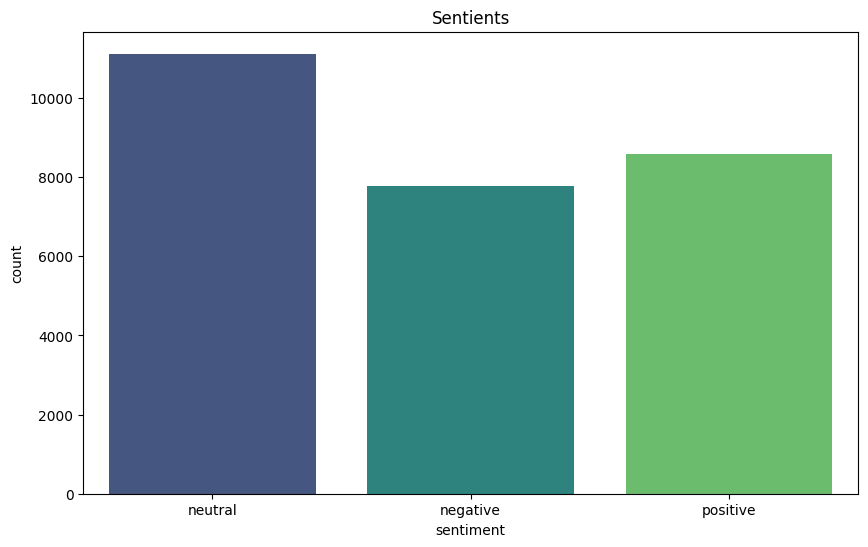

In [70]:
plt.figure(figsize=(10,6))
sns.countplot(x= 'sentiment', data=df, palette='viridis')
plt.title('Sentients')
plt.show()

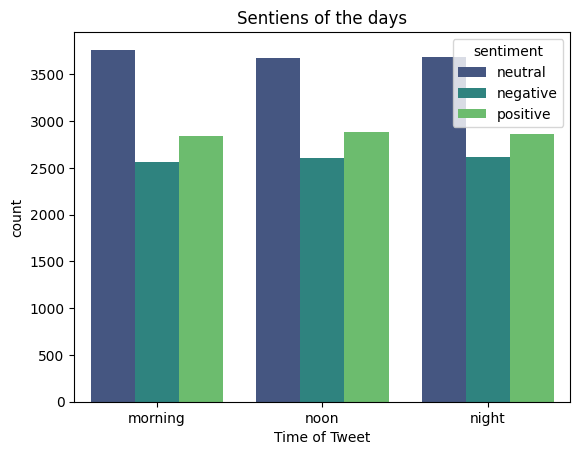

In [71]:
plt.Figure(figsize=(10,6))
sns.countplot(x='Time of Tweet',data=df,palette='viridis',hue='sentiment')
plt.title("Sentiens of the days")
plt.show()

Text(0, 0.5, 'Age od user')

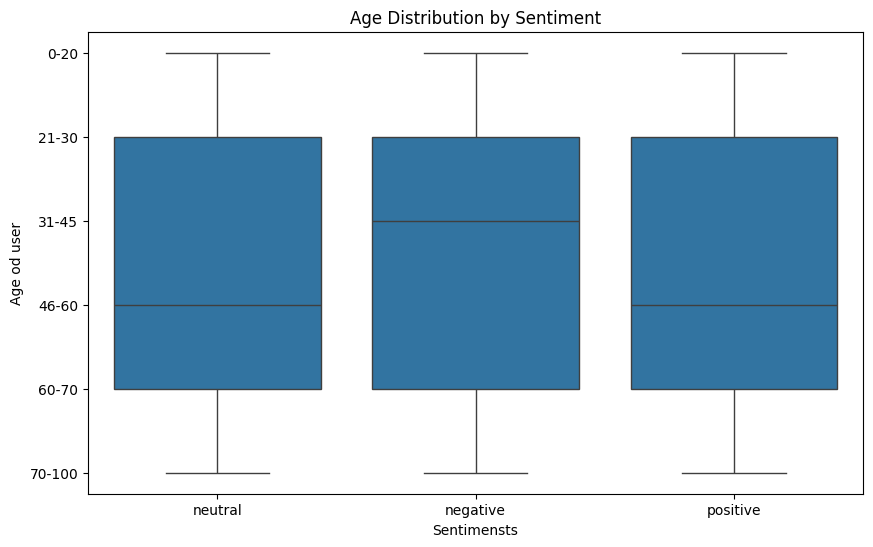

In [72]:
plt.figure(figsize=(10,6))
sns.boxplot(x='sentiment',y='Age of User',data=df)
plt.title("Age Distribution by Sentiment")
plt.xlabel("Sentimensts")
plt.ylabel('Age od user')

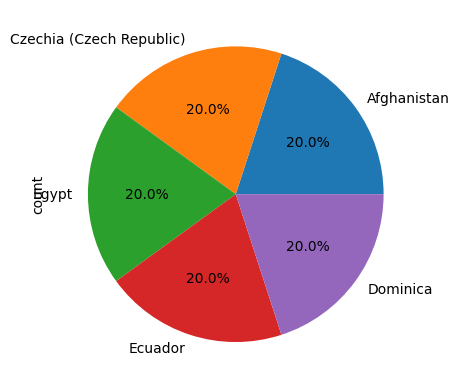

In [73]:
plt.Figure(figsize=(10,8))
df['Country'].value_counts().head(5).plot(kind='pie',autopct="%1.1f%%")
plt.show()

In [74]:
def plot_wordcloud(sent_type,color):

    text="".join(text for text in df[df['sentiment']==sent_type]['text'].astype(str))
    wordcloud=WordCloud(background_color=color,width=900,height=400).generate(text)
    plt.figure(figsize = (10, 5))
    plt.imshow(wordcloud,interpolation='bilinear')
    plt.title(f'Most Common Words in {sent_type.capitalize()} Tweets')
    plt.show()
    

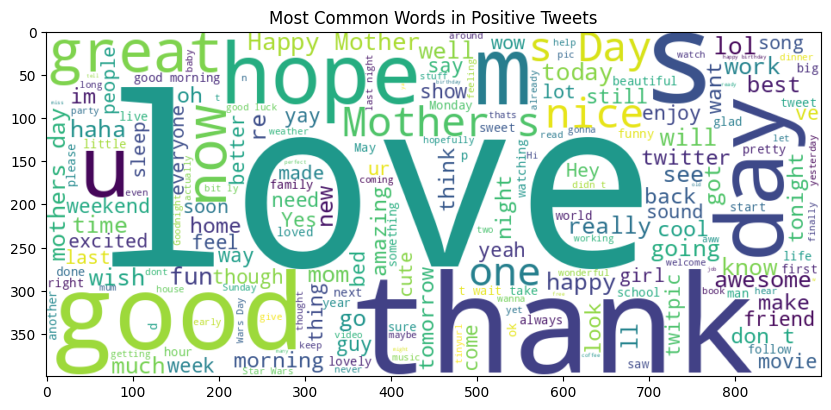

In [75]:
plot_wordcloud('positive','white')

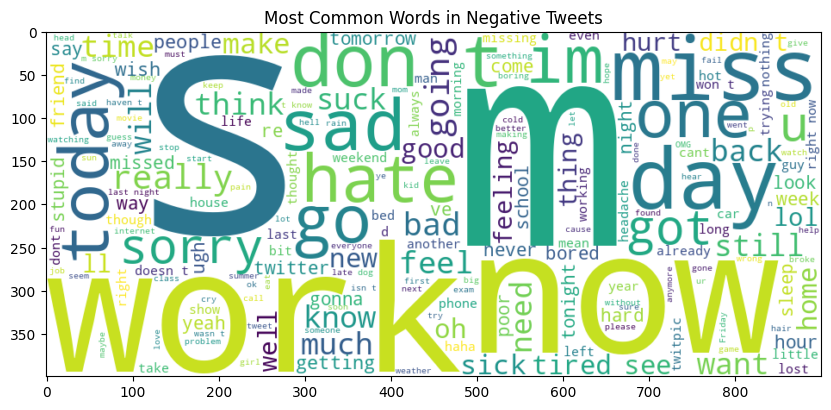

In [76]:
plot_wordcloud('negative','white')

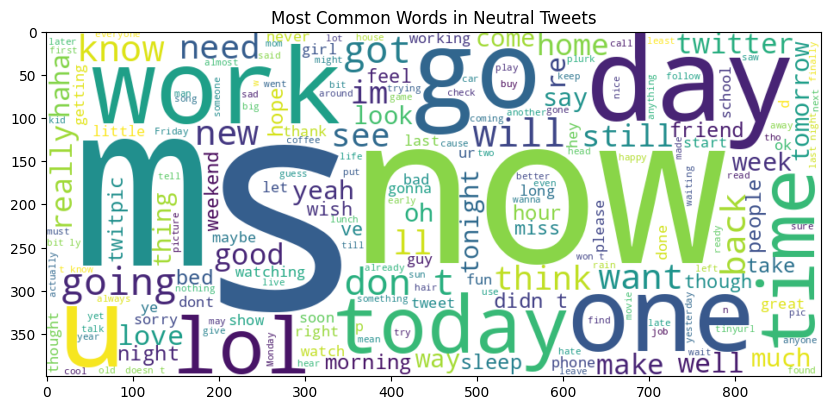

In [77]:
plot_wordcloud('neutral','white')

cleaning raw text

In [78]:
df['text']

0                      I`d have responded, if I were going
1            Sooo SAD I will miss you here in San Diego!!!
2                                my boss is bullying me...
3                           what interview! leave me alone
4         Sons of ****, why couldn`t they put them on t...
                               ...                        
27476     wish we could come see u on Denver  husband l...
27477     I`ve wondered about rake to.  The client has ...
27478     Yay good for both of you. Enjoy the break - y...
27479                           But it was worth it  ****.
27480       All this flirting going on - The ATG smiles...
Name: text, Length: 27481, dtype: object

In [79]:
def clean_text(text):
    text=str(text).lower()
    text=re.sub(r"[s\^\w]","",text)
    text=re.sub(r"http\S+|https\S+|www\S+","",text,flags=re.MULTILINE)
    text=re.sub(r'\@\w+|\#',"",text)

    return text


In [80]:
df['clean_text']=df['text'].apply(clean_text)

In [81]:
df['clean_text']

0                              `  ,    
1                                   !!!
2                                   ...
3                                  !   
4                     ****,  `         
                      ...              
27476                               `  
27477     `    .        . , `          
27478               .    -             
27479                             ****.
27480                     -   . .  (())
Name: clean_text, Length: 27481, dtype: object

In [82]:
le=LabelEncoder()
df['target']=le.fit_transform(df['sentiment'])

In [84]:
df['target'].value_counts()

target
1    11118
2     8582
0     7781
Name: count, dtype: int64